[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


✅ Loaded 2484 resumes
🧹 Cleaning resumes...
✅ Cleaning done!


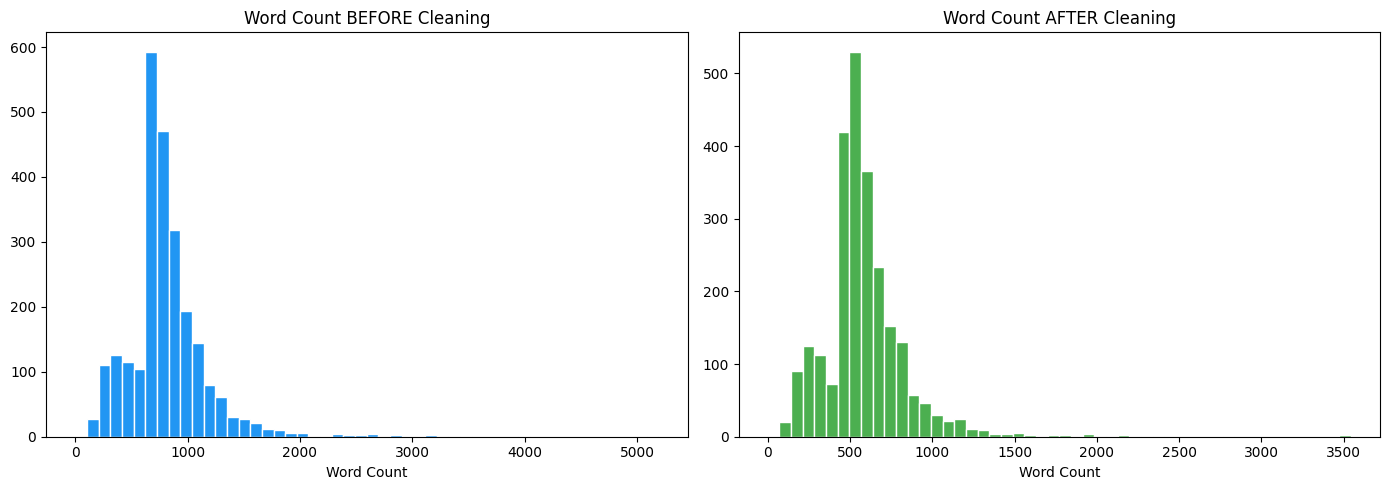

✅ Plot saved → results/plots/cleaned_word_count_comparison.png
✅ Cleaned dataset saved → data/resume_dataset.csv
   Columns now: ['ID', 'Resume_str', 'Resume_html', 'Category', 'word_count', 'experience_level', 'clean_text', 'word_count_before', 'word_count_after']


In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('punkt')

# ── Cell 2: Load Data ─────────────────────────────────────────────────────────
df = pd.read_csv("../data/resume_dataset.csv")
print(f"✅ Loaded {len(df)} resumes")

# ── Cell 3: Clean Function ────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = BeautifulSoup(str(text), "html.parser").get_text()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# ── Cell 4: Apply Cleaning ────────────────────────────────────────────────────
print("🧹 Cleaning resumes...")
df['clean_text'] = df['Resume_str'].apply(clean_text)
print("✅ Cleaning done!")

# ── Cell 5: Compare word counts before vs after ───────────────────────────────
df['word_count_before'] = df['Resume_str'].apply(lambda x: len(str(x).split()))
df['word_count_after']  = df['clean_text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['word_count_before'], bins=50, color='#2196F3', edgecolor='white')
axes[0].set_title('Word Count BEFORE Cleaning')
axes[0].set_xlabel('Word Count')

axes[1].hist(df['word_count_after'], bins=50, color='#4CAF50', edgecolor='white')
axes[1].set_title('Word Count AFTER Cleaning')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig("../results/plots/cleaned_word_count_comparison.png", dpi=150)
plt.show()
print("✅ Plot saved → results/plots/cleaned_word_count_comparison.png")

# ── Cell 6: Save cleaned dataset ──────────────────────────────────────────────
df.to_csv("../data/resume_dataset.csv", index=False)
print("✅ Cleaned dataset saved → data/resume_dataset.csv")
print(f"   Columns now: {df.columns.tolist()}")